# Chapitre 7 — EDA analytique

**Durée estimée : 10-12 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Analyser** la distribution d'une variable et interpréter ses caractéristiques statistiques
2. **Identifier** les relations entre variables (corrélation, associations)
3. **Comparer** des sous-populations et détecter des patterns significatifs
4. **Formuler** des hypothèses à partir des observations et éviter les pièges d'interprétation

---

## 7.2 Analyse univariée

### Qu'est-ce que l'analyse univariée ?

Scénario : Imaginez que vous recevez une base de données sur 1 000 athlètes. Vous avez leur âge, leur poids, leur sport et leur salaire. Pour l'instant, vous décidez de ne regarder que la colonne "Âge".

Questions :

L'isolement : "Si je calcule la moyenne d'âge, est-ce que j'ai besoin de savoir quel sport ils pratiquent ou combien ils pèsent ?"

L'étymologie : "Dans 'Univarié', on entend 'Uni' et 'Varié'. À votre avis, cela signifie qu'on étudie combien de variables à la fois ?"

L'utilité : "Pourquoi est-il crucial de bien connaître chaque colonne individuellement avant de chercher à savoir si elles sont liées entre elles (ex: est-ce que le poids influence le salaire) ?"

L'objectif : L'analyse univariée consiste à examiner chaque variable (colonne) de manière isolée pour en comprendre la "personnalité" (sa tendance centrale, sa dispersion et sa forme).

L'analyse **univariée** examine une seule variable à la fois pour comprendre sa distribution.

### Statistiques de tendance centrale

In [1]:
import pandas as pd
import numpy as np

# Création d'un DataFrame d'exemple
np.random.seed(42)
df = pd.DataFrame({
    'age': [25, 30, 35, 28, 32, 45, 29, 31, 27, 33, 
            26, 34, 38, 29, 31, 42, 28, 30, 35, 27],
    'revenus': [35000, 42000, 55000, 38000, 48000, 75000, 40000, 45000, 36000, 50000,
                34000, 52000, 62000, 41000, 46000, 68000, 39000, 43000, 54000, 37000]
})

print("Aperçu du DataFrame :")
print(df.head(10))
print(f"\nNombre d'observations : {len(df)}")

Aperçu du DataFrame :
   age  revenus
0   25    35000
1   30    42000
2   35    55000
3   28    38000
4   32    48000
5   45    75000
6   29    40000
7   31    45000
8   27    36000
9   33    50000

Nombre d'observations : 20


In [2]:
# Mesures de centralité
moyenne = df['age'].mean()       # Sensible aux outliers
mediane = df['age'].median()     # Robuste aux outliers
mode = df['age'].mode()[0]       # Valeur la plus fréquente

print(f"Moyenne : {moyenne:.2f}")
print(f"Médiane : {mediane:.2f}")
print(f"Mode : {mode}")

Moyenne : 31.75
Médiane : 30.50
Mode : 27


**Quand utiliser quoi ?**

| Mesure | Quand l'utiliser | Exemple |
|--------|------------------|---------|
| **Moyenne** | Distribution symétrique | Taille des personnes |
| **Médiane** | Distribution asymétrique ou outliers | Salaires (PDG vs employés) |
| **Mode** | Variables catégorielles ou multimodales | Taille de vêtements |

---

### Statistiques de dispersion

**Le Coefficient de Variation (CV)**

"Comment savoir qui est le plus régulier : un éléphant qui varie de 50 kg ou une fourmis qui varie de 50 grammes ?"

**Scénario : Le match des investissements**
Imaginez deux placements financiers :

* **Action A (Luxe) :** Prix moyen de 1 000 €, avec un écart-type (variation) de 100 €.
* **Action B (Penny Stock) :** Prix moyen de 10 €, avec un écart-type de 5 €.

**Questions :**

1. **L'illusion des chiffres :** "À première vue, laquelle semble la plus risquée car son prix bouge le plus en valeur absolue (en euros) ?" *(Réponse attendue : l'Action A, car 100 € > 5 €)*.
2. **La proportion :** "Si on rapporte l'écart-type au prix moyen, quelle part du prix représente la variation pour l'Action A ? Et pour l'Action B ?"
3. **Le verdict :** "L'Action B varie de la moitié de son prix (50%), alors que l'Action A ne varie que de 10%. Laquelle est réellement la plus instable ?"

L'écart-type seul ne suffit pas pour comparer des groupes différents. Le **Coefficient de Variation** sert à mesurer la **dispersion relative**. C'est l'écart-type divisé par la moyenne.

> **Formule :**  (souvent exprimé en %)

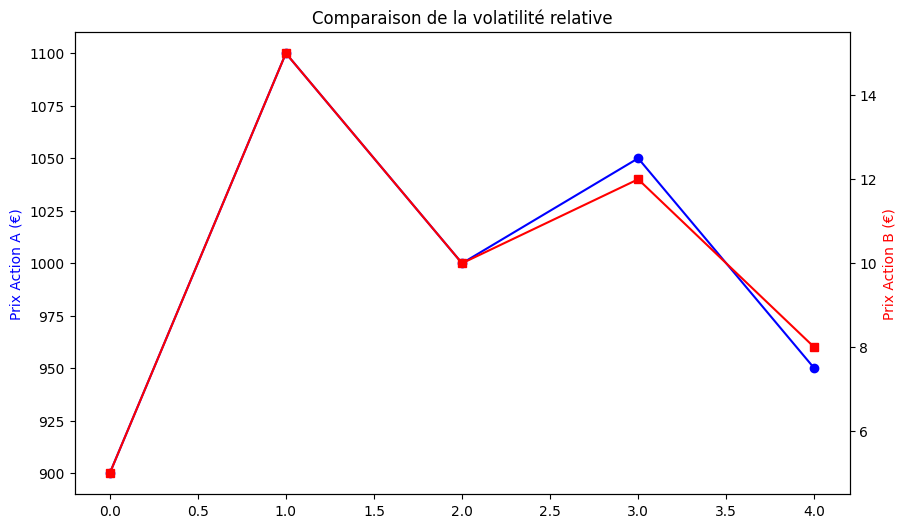

In [9]:
### 🛠️ Visualisation Python : Pourquoi l'écart-type peut être trompeur

import pandas as pd
import matplotlib.pyplot as plt

# Création des données pour nos deux actions
data = {
    'Action_A': [900, 1100, 1000, 1050, 950], # Moyenne 1000, Écart-type ~70
    'Action_B': [5, 15, 10, 12, 8]           # Moyenne 10, Écart-type ~3.5
}
df = pd.DataFrame(data)

# Calculs
cv_a = df['Action_A'].std() / df['Action_A'].mean()
cv_b = df['Action_B'].std() / df['Action_B'].mean()

# Graphique
fig, ax1 = plt.subplots(figsize=(10, 6))

# On utilise deux échelles car les prix sont trop différents
ax1.plot(df['Action_A'], color='blue', marker='o', label=f"Action A (CV: {cv_a:.1%})")
ax2 = ax1.twinx() 
ax2.plot(df['Action_B'], color='red', marker='s', label=f"Action B (CV: {cv_b:.1%})")

plt.title("Comparaison de la volatilité relative")
ax1.set_ylabel("Prix Action A (€)", color='blue')
ax2.set_ylabel("Prix Action B (€)", color='red')
plt.show()

In [11]:
# ecart-type 
ecart_type_a = df['Action_A'].std()
ecart_type_b = df['Action_B'].std()

print(f"Ecart-type Action A: {ecart_type_a:.2f}")
print(f"Ecart-type Action B: {ecart_type_b:.2f}")
print(f"Coefficient de Variation Action A: {cv_a:.2%}")
print(f"Coefficient de Variation Action B: {cv_b:.2%}")

Ecart-type Action A: 79.06
Ecart-type Action B: 3.81
Coefficient de Variation Action A: 7.91%
Coefficient de Variation Action B: 38.08%


**Interprétation du coefficient de variation (CV) :**
- CV < 15% : Faible dispersion
- 15% < CV < 30% : Dispersion modérée
- CV > 30% : Forte dispersion

**Tableau de synthèse (Mise à jour)**

| Notion | Question à se poser | Ce que ça mesure | Utilité |
| --- | --- | --- | --- |
| **Écart-type** | "De combien on s'éloigne de la moyenne ?" | La dispersion absolue. | Pour des données de même unité. |
| **CV (%)** | "C'est beaucoup par rapport à la moyenne ?" | La dispersion **relative**. | Pour comparer des groupes d'échelles différentes. |

---

### Forme de la distribution

#### Le Skewness (L'Asymétrie)

Dans un monde idéal, tout est symétrique, voir la courbe de Gauss (la cloche parfaite). Mais la réalité est souvent 'tordue'."

**Scénario : Les salaires dans une start-up**
Imaginez une petite entreprise de 10 employés. 9 gagnent 2 000 €/mois. Le patron gagne 20 000 €/mois.

**Questions :**

1. **La forme :** "Si on dessine les bâtons pour chaque salaire, est-ce que la 'bosse' est au milieu ? Où se situe la longue traîne (les rares salaires très élevés) ?"
2. **L'influence :** "Si le patron double son salaire, est-ce que la 'bosse' (le salaire le plus fréquent) bouge ? Et la moyenne ?"
3. **La logique :** "Comment appelleriez-vous une distribution qui n'est pas un miroir parfait ? Si elle 'penche' à gauche, qu'est-ce que cela nous dit sur les données exceptionnelles ?"

Le **Skewness** indique de quel côté se trouve la "queue" de la distribution.

* **Queue à droite** = Skewness positif (ex: les revenus).
* **Queue à gauche** = Skewness négatif (ex: l'âge au décès).

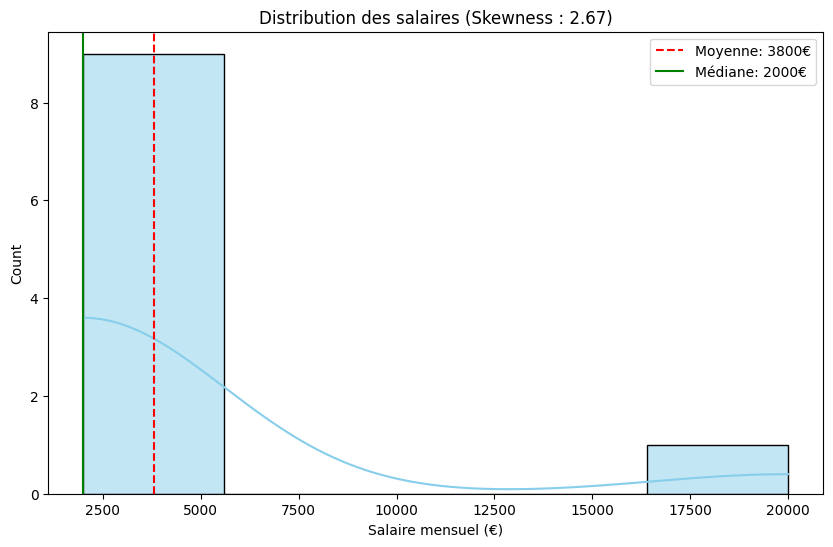

In [ ]:
### 🛠️ Visualisation Python : Skewness Positif

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# Simulation du scénario (9 employés à 2000€, 1 patron à 20000€)
salaires = [2000]*9 + [20000]

plt.figure(figsize=(10, 6))
sns.histplot(salaires, kde=True, color="skyblue")
plt.axvline(np.mean(salaires), color='red', linestyle='--', label=f"Moyenne: {np.mean(salaires):.0f}€")
plt.axvline(np.median(salaires), color='green', linestyle='-', label=f"Médiane: {np.median(salaires):.0f}€")

plt.title(f"Distribution des salaires (Skewness : {skew(salaires):.2f})")
plt.xlabel("Salaire mensuel (€)")
plt.legend()
plt.show()

# Remarquez comment la moyenne est "aspirée" par le salaire du patron, alors que la bosse (le mode/médiane) reste à gauche. C'est un **Skewness positif**.

#### Le Kurtosis (L'Aplatissement)

**Le point de départ :** Prenez deux classes qui ont la même note moyenne (ex: 10/20).

**Scénario : Le comportement des notes**

* **Classe A :** Presque tout le monde a entre 9 et 11. C'est très serré.
* **Classe B :** Beaucoup de 0 et beaucoup de 20, avec quelques notes au milieu.

**Questions :**

1. **La silhouette :** "Si vous deviez dessiner ces deux classes, laquelle aurait le sommet le plus pointu ? Laquelle ressemblerait à un plateau ?"
2. **Le risque / Les surprises :** "Dans quelle classe avez-vous le plus de chances de trouver une note 'extrême' (un génie ou un élève en grande difficulté) ?"
3. **La comparaison :** "Si la courbe normale est notre référence (le juste milieu), comment décririez-vous la 'fatigue' ou la 'nervosité' de la courbe B par rapport à la courbe A ?"

Le **Kurtosis** ne parle pas de la moyenne, mais de la **concentration** et de la probabilité d'avoir des **valeurs extrêmes** (les "queues lourdes").

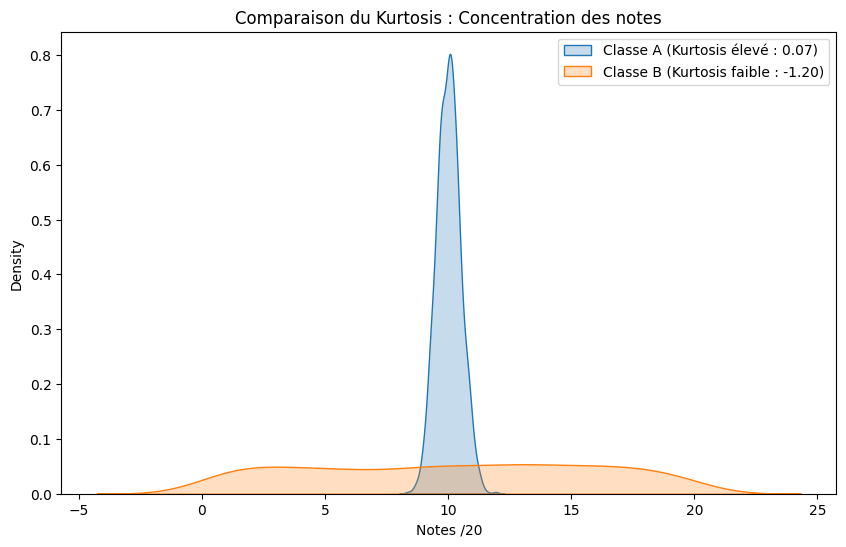

In [7]:

### 🛠️ Visualisation Python : Comparer l'aplatissement

from scipy.stats import kurtosis

# Simulation des données
classe_A = np.random.normal(10, 0.5, 1000) # Très concentré (Leptokurtique)
classe_B = np.random.uniform(0, 20, 1000)  # Très étalé (Platykurtique)

plt.figure(figsize=(10, 6))
sns.kdeplot(classe_A, label=f"Classe A (Kurtosis élevé : {kurtosis(classe_A):.2f})", fill=True)
sns.kdeplot(classe_B, label=f"Classe B (Kurtosis faible : {kurtosis(classe_B):.2f})", fill=True)

plt.title("Comparaison du Kurtosis : Concentration des notes")
plt.xlabel("Notes /20")
plt.legend()
plt.show()

#Un Kurtosis élevé signifie une courbe "pointue" avec des queues fines (peu d'outliers), alors qu'un Kurtosis faible (ou négatif) montre une courbe aplatie.


**Tableau de synthèse**

| Notion | Question à se poser | Ce que ça mesure | Indice visuel |
| --- | --- | --- | --- |
| **Skewness** | "Est-ce que c'est penché ?" | Le manque de symétrie. | La longueur de la **queue**. |
| **Kurtosis** | "Est-ce que c'est pointu ou plat ?" | La concentration et la fréquence des valeurs extrêmes. | La hauteur du **pic** et l'épaisseur des extrémités. |

**Application concrète de ces deux indicateurs :**

Le prix des maisons (Skewness positif) : La majorité des maisons ont un prix "standard", mais quelques villas de luxe créent une traîne géante à droite.

Les rendements boursiers (Kurtosis élevé) : La plupart du temps, les variations sont minimes, mais les krachs boursiers sont des événements extrêmes qui rendent les "queues" de la distribution très lourdes.

---

### ✍️ Exercice 7.1 : Analyse univariée complète (15 min)

In [ ]:
import pandas as pd
import numpy as np

# Données de salaires
np.random.seed(42)
salaires = np.concatenate([
    np.random.normal(45000, 8000, 900),   # Employés
    np.random.normal(80000, 15000, 90),   # Managers
    np.random.normal(200000, 50000, 10)   # Dirigeants
])
df = pd.DataFrame({'salaire': salaires})

# 1. Calculez les mesures de centralité
moyenne = df['salaire'].mean()
mediane = df['salaire'].median()
print(f"Moyenne : {moyenne:,.0f} €")
print(f"Médiane : {mediane:,.0f} €")

# 2. Pourquoi la moyenne et la médiane sont-elles différentes ?
# Réponse : La distribution est asymétrique (skewed), donc la moyenne est influencée par les valeurs extrêmes.

# 3. Laquelle utiliseriez-vous pour représenter le "salaire typique" ?
# Réponse : La médiane car elle est moins sensible aux valeurs extrêmes.

# 4. Calculez le coefficient de variation
cv = df['salaire'].std() / df['salaire'].mean()
print(f"CV : {cv:.1%}")
# Interprétation : Un CV élevé indique une grande variabilité des salaires par rapport à la moyenne.

# 5. Calculez le skewness et interprétez
skewness = df['salaire'].skew()
print(f"Skewness : {skewness:.2f}")
# Interprétation : Un skewness positif indique une distribution asymétrique vers la droite (la queue est plus longue à droite), ce qui signifie qu'il y a des salaires plus élevés qui influencent la moyenne.

Moyenne : 49,818 €
Médiane : 46,188 €
CV : 40.5%
Skewness : 5.24
